# 1. Model Structure 模型结构

线性回归算是回归任务中比较简单的一种模型，它的模型结构可以表示如下：
$$ f(x)=w^Tx^* $$

这里$x^*=[x^T,1]^T$，$x\\in R^n$，所以$w\\in R^{n+1}$，$w$即是模型需要学习的参数

In [35]:
import numpy as np

In [44]:
# create some samples
X = np.linspace(0, 100, 100) # [0,100], step equal, 100 numbers
X = np.c_[X, np.ones(100)] # create a matrix, the second column is all 1
w = np.asarray([2, 3]) # create `w` matrix,
Y = X.dot(w)
X = X.astype('float')
Y = Y.astype('float')

In [45]:
X.shape

(100, 2)

In [46]:
print(w.shape)
w

(2,)


array([2, 3])

In [47]:
print(Y.shape)

(100,)


In [48]:
# 添加噪声，生成与X[:,0]形状相同的正态分布（高斯分布）随机数，均值为 0，标准差为 1
X[:,0] += np.random.normal(size =X[:, 0].shape) * 3
X

array([[ -5.02233394,   1.        ],
       [ -0.10233839,   1.        ],
       [  5.74263128,   1.        ],
       [  8.52355788,   1.        ],
       [  8.20994242,   1.        ],
       [  8.21752744,   1.        ],
       [  8.95050144,   1.        ],
       [  8.30376822,   1.        ],
       [ 10.70661111,   1.        ],
       [  3.99028235,   1.        ],
       [ 10.62778016,   1.        ],
       [  7.89684105,   1.        ],
       [ 16.96425463,   1.        ],
       [ 13.72748674,   1.        ],
       [ 14.25626828,   1.        ],
       [ 10.23893528,   1.        ],
       [ 14.49043172,   1.        ],
       [ 20.21043857,   1.        ],
       [ 23.9266214 ,   1.        ],
       [ 19.50014893,   1.        ],
       [ 20.23053514,   1.        ],
       [ 20.90698553,   1.        ],
       [ 27.27544985,   1.        ],
       [ 23.51504679,   1.        ],
       [ 23.31107603,   1.        ],
       [ 22.2765834 ,   1.        ],
       [ 25.385288  ,   1.        ],
 

In [49]:
Y = Y.reshape(100,1) # 将Y从行形式转为列形式，构成一个矩阵
print(Y.shape)
Y

(100, 1)


array([[  3.        ],
       [  5.02020202],
       [  7.04040404],
       [  9.06060606],
       [ 11.08080808],
       [ 13.1010101 ],
       [ 15.12121212],
       [ 17.14141414],
       [ 19.16161616],
       [ 21.18181818],
       [ 23.2020202 ],
       [ 25.22222222],
       [ 27.24242424],
       [ 29.26262626],
       [ 31.28282828],
       [ 33.3030303 ],
       [ 35.32323232],
       [ 37.34343434],
       [ 39.36363636],
       [ 41.38383838],
       [ 43.4040404 ],
       [ 45.42424242],
       [ 47.44444444],
       [ 49.46464646],
       [ 51.48484848],
       [ 53.50505051],
       [ 55.52525253],
       [ 57.54545455],
       [ 59.56565657],
       [ 61.58585859],
       [ 63.60606061],
       [ 65.62626263],
       [ 67.64646465],
       [ 69.66666667],
       [ 71.68686869],
       [ 73.70707071],
       [ 75.72727273],
       [ 77.74747475],
       [ 79.76767677],
       [ 81.78787879],
       [ 83.80808081],
       [ 85.82828283],
       [ 87.84848485],
       [ 89

Text(0, 0.5, 'Y')

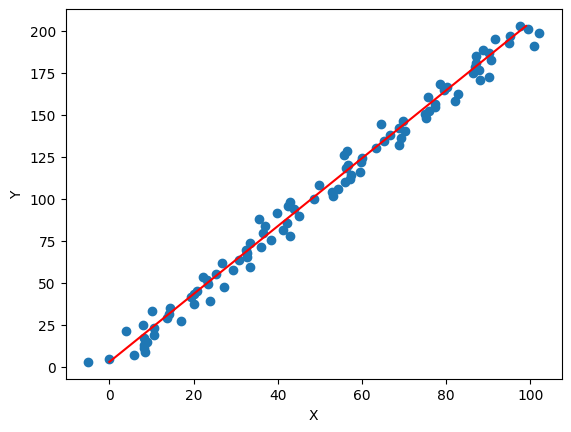

In [50]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.scatter(X[:,0],Y)
plt.plot(np.arange(0,100).reshape((100,1)),Y,'r')
plt.xlabel('X')
plt.ylabel('Y')

# 2.损失函数
利用等式$y=3x+2$造了一些伪数据，并给$x$添加了一些噪声数据，线性回归的目标即在只有$x,y$的情况下，求解出最优解：$w=[3,2]^T$；可以通过MSE（均方误差）来衡量$f(x)$与$y$的相近程度：

$$
L(w)=\sum_{i=1}^m(y_i-f(x_i))^2=\sum_{i=1}^m(y_i-w^Tx_i^*)^2=(Y-X^*w)^T(Y-X^*w)
$$

这里$m$表示样本量，本例中$m=100$，$x_i,y_i$表示第$i$个样本，$X^*\in R^{m \times (n+1)},Y\in R^{m\times 1}$，损失函数$L(w)$本质上是关于$w$的函数，通过求解最小的$L(w)$即可得到$w$的最优解：

$$
w^*=arg \min_{w}L(w)
$$


## 方法一：直接求闭式解

而对$\min L(w)$的求解很明显是一个凸问题（海瑟矩阵${X^*}^TX^*$正定），我们可以直接通过求解$\frac{dL}{dw}=0$得到$w^*$，梯度推导如下：

$$
\frac{dL}{dw}=-2\sum_{i=1}^m(y_i-w^Tx_i^*)x_i^*=-2{X^*}^T(Y-X^*w)\\
$$
令$\frac{dL}{dw}=0$，可得：$w^*=({X^*}^TX^*)^{-1}{X^*}^TY$，实际情景中数据不一定能满足${X^*}^TX$是满秩（比如$m<n$的情况下，$w$的解有无数种），所以没法直接求逆，我们可以考虑用如下的方式求解：
$$
{X^*}^+=\lim_{\alpha\rightarrow0}({X^*}^TX^*+\alpha I)^{-1}{X^*}^T
$$

上面的公式即是Moore-Penrose伪逆的定义，但实际求解更多是通过SVD的方式：

$$
{X^*}^+=VD^+U^T
$$

其中，$U,D,V$是矩阵$X^*$做奇异值分解（SVD）后得到的矩阵，对角矩阵$D$的伪逆$D^+$由其非零元素取倒数之后再转置得到，通过伪逆求解到的结果有如下优点：

（1）当$w$有解时，$w^*={X^*}^+Y$是所有解中欧几里得距离$||w||_2$最小的一个；

（2）当$w$无解时，通过伪逆得到的$w^*$是使得$X^*w^*$与$Y$的欧几里得距离$||X^*w^*-Y||_2$最小

## 方法二：梯度下降求解

但对于数据量很大的情况，求闭式解的方式会让内存很吃力，我们可以通过随机梯度下降法（SGD）对$w$进行更新，首先随机初始化$w$，然后使用如下的迭代公式对$w$进行迭代更新：
$$
w:=w-\eta\frac{dL}{dw}
$$

# 3.模型训练
目前推导出了$w$的更新公式，接下来编码训练过程：

In [51]:
#参数初始化
w = np.random.random(size = (2,1))
# 更新参数
epoches = 100
eta = 0.0000001
losses = []#记录loss变化
for _ in range(epoches):
    dw = -2*X.T.dot(Y-X.dot(w))
    w = w-eta*dw
    losses.append((Y-X.dot(w)).T.dot(Y-X.dot(w)).reshape(-1))
w

array([[2.03561128],
       [0.24121903]])

In [33]:
losses

[array([489051.8116116]),
 array([426376.04800777]),
 array([371799.45321054]),
 array([324275.42588122]),
 array([282892.60996222]),
 array([246857.41783528]),
 array([215478.81189477]),
 array([188155.05269646]),
 array([164362.15955419]),
 array([143643.86229639]),
 array([125602.85148976]),
 array([109893.15933802]),
 array([96213.52514597]),
 array([84301.6181203]),
 array([73929.00671909]),
 array([64896.7780786]),
 array([57031.72351222]),
 array([50183.01693179]),
 array([44219.32249432]),
 array([39026.27600817]),
 array([34504.29180019]),
 array([30566.6529868]),
 array([27137.84852645]),
 array([24152.12516373]),
 array([21552.22649605]),
 array([19288.29498224]),
 array([17316.91583722]),
 array([15600.28447781]),
 array([14105.48155393]),
 array([12803.8416626]),
 array([11670.40363889]),
 array([10683.43188202]),
 array([9823.99953733]),
 array([9075.6255408]),
 array([8423.95856596]),
 array([7856.5018121]),
 array([7362.3733564]),
 array([6932.09747402]),
 array([6557.4

Text(0, 0.5, 'Y')

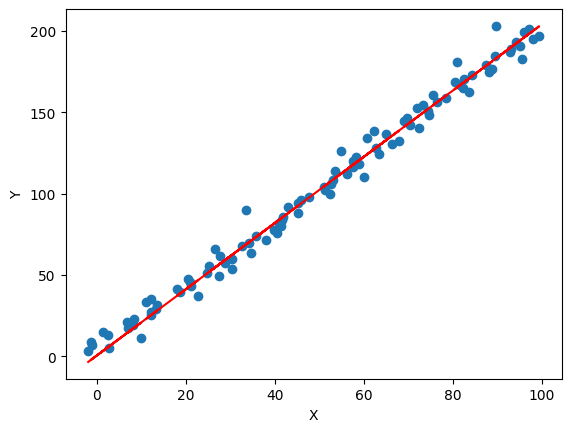

In [34]:
#可视化
plt.scatter(X[:,0],Y)
plt.plot(X[:,0],X.dot(w),'r')
plt.xlabel('X')
plt.ylabel('Y')

Text(0, 0.5, 'loss')

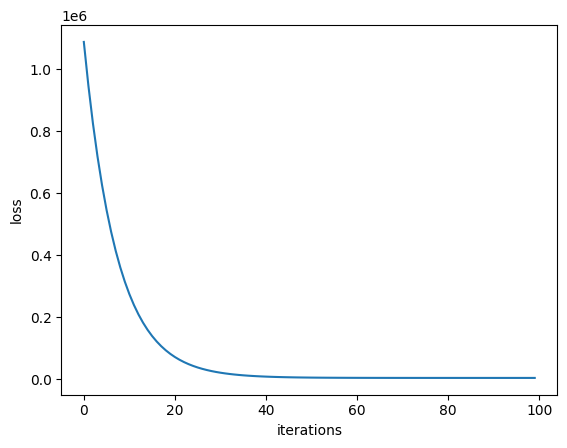

In [52]:
#loss变化
plt.plot(losses)
plt.xlabel('iterations')
plt.ylabel('loss')

In [53]:
# 当然也可以直接求显式解
w = np.linalg.pinv(X).dot(Y)
w

array([[2.00046427],
       [2.71648832]])

Text(0, 0.5, 'Y')

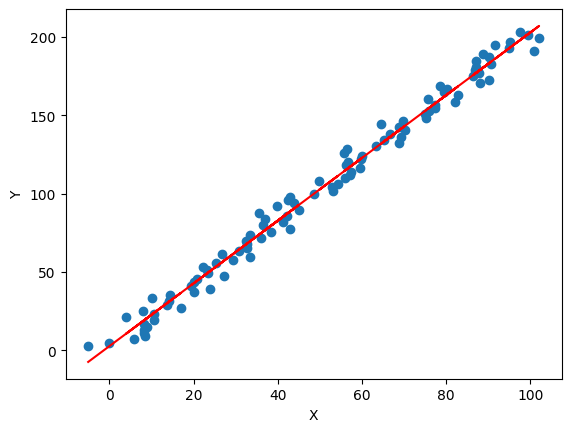

In [54]:
# 可视化
plt.scatter(X[:,0],Y)
plt.plot(X[:,0],X.dot(w),'r')
plt.xlabel('X')
plt.ylabel('Y')

# 4.问题讨论
在上面的梯度下降的例子中存在一个问题，$w_1$基本能收敛到2附近，而$w_2$却基本在0附近，很难收敛到2.7，说明$w_1$比$w_2$更容易收敛($w=[w_1,w_2]^T$)，这很容易理解，模型可以写作：$f(x)=x*w_1+1\cdot w_2$，如果$x$量纲比1大很多，为了使$f(x)$变化，只需更新少量的$w_1$就能达到目的，而$w_2$的更新动力略显不足；可以考虑用如下方式：

（1）对输入$X$进行归一化，使得$x$无量纲，$w_1,w_2$的更新动力一样（后面封装代码时添加上），如下图；
![avatar](./source/01_归一化对梯度下降的影响.png)

（2）梯度更新时，$w_1,w_2$使用了一样的学习率，可以让$w_1,w_2$使用不一样的学习率进行更新，比如对$w_2$使用更大的学习率进行更新（可以利用学习率自适应一类的梯度下降法，比如adam），如下图：
![avatar](./source/01_adam.png)

# 5.封装与测试
接下来简单封装线性回归模型，并放到ml_models.linear_model模块便于后续使用；

In [64]:
class LinearRegression(object):
    """线性回归模型实现

    该类实现了线性回归算法，支持配置是否拟合截距项、选择优化器、
    特征标准化处理等功能，通过迭代优化方法求解模型参数。
    """
    def __init__(self, fit_intercept = True, optimizer = 'sgd', if_standard = True,
                 epochs = 10, lr = 1e-2, batch_size = 1):
        """初始化线性回归模型参数

        :param fit_intercept: bool类型，可选，默认值为True
            是否在模型中拟合截距项（偏置项）。若为True，模型会额外学习一个常数项；
            若为False，模型仅学习特征的系数，不包含截距项。

        :param optimizer: str类型，可选，默认值为'sgd'
            模型训练使用的优化器名称。目前默认支持'sgd'（随机梯度下降），
            可扩展支持其他优化器（如'gd'梯度下降、'momentum'动量法等）。

        :param if_standard: bool类型，可选，默认值为True
            是否对输入特征进行标准化处理。若为True，训练过程中会计算每个特征的均值和标准差，
            并将特征转换为均值为0、标准差为1的标准化特征；若为False，则不进行标准化。

        :param epochs: int类型，可选，默认值为10
            训练迭代的轮数（完整遍历训练集的次数）。轮数越多，模型在训练集上的迭代次数越多，
            需注意避免过拟合，通常需要根据验证集性能调整。

        :param lr: float类型，可选，默认值为1e-2（即0.01）
            学习率（步长），控制优化过程中参数更新的幅度。学习率过大会导致收敛不稳定，
            过小则会延长训练时间，需根据实际场景调整（通常为0.001~0.1之间）。

        :param batch_size: int类型，可选，默认值为1
            每次参数更新使用的样本批量大小。当为1时，为随机梯度下降（SGD）；
            当等于训练集大小时，为批量梯度下降（BGD）；当为1~训练集大小之间时，
            为小批量梯度下降（MBGD）。需为正整数，且不超过训练样本总数。

        :ivar w: 模型参数（系数），初始化为None，训练后存储特征对应的权重
        :ivar feature_mean: 特征均值，当if_standard为True时有效，存储各特征的均值
        :ivar feature_std: 特征标准差，当if_standard为True时有效，存储各特征的标准差
        """
        self.w = None
        self.fit_intercept = fit_intercept
        self.optimizer = optimizer
        self.if_standard = if_standard
        if if_standard:
            self.feature_mean = None
            self.feature_std = None
        self.epochs = epochs
        self.eta = lr
        self.batch_size = batch_size

    def init_params(self, n_features):
        """初始化模型参数（权重矩阵）

        该方法根据输入特征的数量，使用随机数初始化模型的权重参数w，
        生成形状为(n_features, 1)的初始权重矩阵，为后续模型训练做准备。

        :param n_features: int类型，正整数
            输入特征的数量（特征维度）。决定了权重矩阵的行数，需与训练数据的特征维度一致。

        :return: None
            无返回值，初始化结果直接存储在实例变量self.w中。

        :ivar self.w: numpy数组，形状为(n_features, 1)
            初始化后的值为[0, 1)区间内的随机浮点数，存储模型的特征权重参数。
        """
        self.w = np.random.random(size = (n_features, 1))


    def _fit_closed_form_solution(self, x, y):
        """
        直接求闭式解
        :param x:
        :param y:
        :return:
        """
        self.w = np.linalg.pinv(x).dot(y)

    def _fit_sgd(self, x, y):
        """
        随机梯度下降求解
        :param x:
        :param y:
        :param epochs:
        :param eta:
        :param batch_size:
        :return:
        """
        x_y = np.c_[x, y]
        # 按batch_size更新w,b
        for _ in range(self.epochs):
            np.random.shuffle(x_y)
            for index in range(x_y.shape[0] // self.batch_size):
                batch_x_y = x_y[self.batch_size * index:self.batch_size * (index + 1)]
                batch_x = batch_x_y[:, :-1]
                batch_y = batch_x_y[:, -1:]

                dw = -2 * batch_x.T.dot(batch_y - batch_x.dot(self.w)) / self.batch_size
                self.w = self.w - self.eta * dw

    def fit(self, x, y):
        # 是否归一化feature
        if self.if_standard:
            self.feature_mean = np.mean(x, axis=0)
            self.feature_std = np.std(x, axis=0) + 1e-8
            x = (x - self.feature_mean) / self.feature_std
        # 是否训练bias
        if self.fit_intercept:
            x = np.c_[x, np.ones_like(y)]
        # 初始化参数
        self.init_params(x.shape[1])
        # 训练模型
        if self.optimizer == 'closed_form':
            self._fit_closed_form_solution(x, y)
        elif self.optimizer == 'sgd':
            self._fit_sgd(x, y)

    def get_params(self):
        """
        输出原始的系数
        :return: w,b
        """
        if self.fit_intercept:
            w = self.w[:-1]
            b = self.w[-1]
        else:
            w = self.w
            b = 0
        if self.if_standard:
            w = w / self.feature_std.reshape(-1, 1)
            b = b - w.T.dot(self.feature_mean.reshape(-1, 1))
        return w.reshape(-1), b

    def predict(self, x):
        """
        :param x:ndarray格式数据: m x n
        :return: m x 1
        """
        if self.if_standard:
            x = (x - self.feature_mean) / self.feature_std
        if self.fit_intercept:
            x = np.c_[x, np.ones(shape=x.shape[0])]
        return x.dot(self.w)

    def plot_fit_boundary(self, x, y):
        """
        绘制拟合结果
        :param x:
        :param y:
        :return:
        """
        plt.scatter(x[:, 0], y)
        plt.plot(x[:, 0], self.predict(x), 'r')



In [65]:
#测试
linear_model = LinearRegression(optimizer ='sgd')
linear_model.fit(X[:, :-1], Y)
predict = linear_model.predict(X[:, :-1])
#查看w
print('w', linear_model.get_params())
#查看标准差
np.std(Y-predict)

w (array([1.98935579]), array([[3.38419249]]))


6.165712762155746

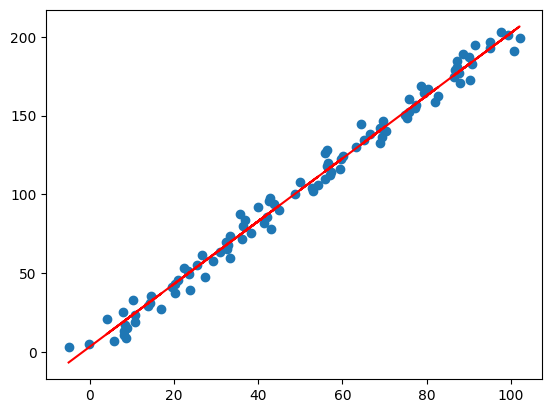

In [66]:
#可视化结果
linear_model.plot_fit_boundary(X[:, :-1], Y)

In [67]:
#测试
linear_model = LinearRegression(optimizer ='closed_form')
linear_model.fit(X[:, :-1], Y)
linear_model.fit(X[:, :-1], Y)
predict = linear_model.predict(X[:, :-1])
#查看w
print('w', linear_model.get_params())
#查看标准差
np.std(Y-predict)

w (array([2.00046427]), array([[2.71648832]]))


6.157298283203773

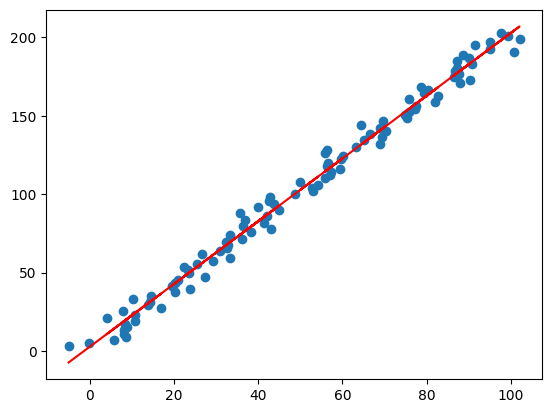

In [68]:
#可视化结果
linear_model.plot_fit_boundary(X[:, :-1], Y)

In [69]:
# 与sklearn对比
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X[:, :-1], Y)
predict = linear_model.predict(X[:, :-1])
# 查看w,b
print('w:', linear_model.coef_, 'b:', linear_model.intercept_)
# 查看标准差
np.std(Y-predict)

w: [[2.00046427]] b: [2.71648832]


6.157298283203774

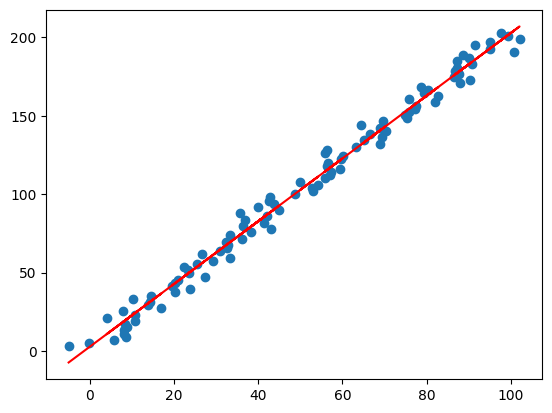

In [70]:
# 可视化结果
x = X[:, :-1]
y = Y
plt.scatter(x[:, 0], y)
plt.plot(x[:, 0], linear_model.predict(x), 'r')